# FUNCTION TRANSFORMATION

Function transformation is the process of changing the position, size, or shape of a mathematical function’s graph using operations such as shifting, stretching, compressing, or reflecting. It is used to understand how equations behave without creating a completely new graph from scratch. By applying transformations, mathematicians, engineers, and data scientists can model real-world situations more easily, analyze patterns, and modify existing functions to fit different conditions or data.

### Types of Funtion Transformation
| Transformation   | Use Case                | Description                                                                        |
| ---------------- | ----------------------- | ---------------------------------------------------------------------------------- |
| Log Transform    | Right-skewed data       | Compresses larger values more than smaller ones to reduce the tail on the right.   |
| Square Transform | Left-skewed data        | Accentuates larger values to stretch the distribution toward the right.            |
| Reciprocal       | Inverting relationships | Replaces each value (x) with (1/x); useful for reversing scales or handling rates. |
| Square Root      | Mildly skewed data      | A moderate way to reduce right skewness compared to the log transform.             |
| Custom           | Domain-specific         | Any user-defined function, such as cleaning text or creating interaction features. |

### Why Use Function Transformers?Handle Skewness: 
* Handle Skewness: Many ML algorithms perform better when data is "Gaussian-like" (symmetric). Function Transformers help correct skewness.
* Mitigate Outliers: By compressing data (e.g., using log), you can reduce the disproportionate impact of extremely high values.
* Linearize Relationships: They can turn non-linear relationships between features and targets into linear ones, making them easier for simple models to capture.
* Pipeline Integration: They allow you to treat custom data cleanup or math as a formal step in an automated pipeline, ensuring the same logic is applied to both training and test data.

In [1]:
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
file_path = "loan.csv" 

loan_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "tanishaj225/loancsv",  
    path=file_path
)

In [3]:
loan_df.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [4]:
loan_df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


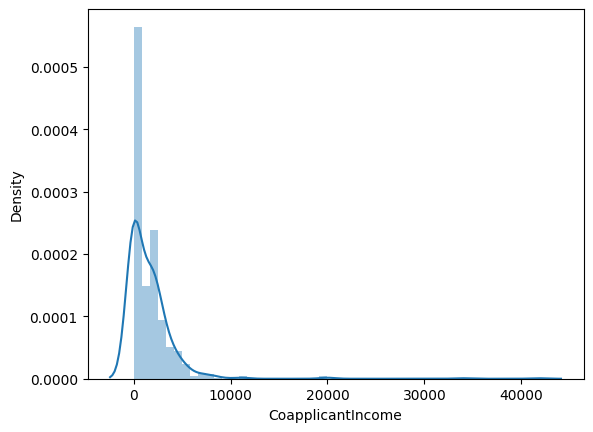

In [6]:
sns.distplot(loan_df.CoapplicantIncome)
plt.show()

For converting the above distribution we have to remove the outliers because they will or can cause some problems while converting it into a normal distribution and then whatever data is left behind we will use the Funtion Transformation to convert it into a normal distribution.

In [7]:
q1 = loan_df.CoapplicantIncome.quantile(0.25)
q3 = loan_df.CoapplicantIncome.quantile(0.75)

In [8]:
IQR = q3 - q1

In [9]:
min = q1 - (1.5 * IQR)
max = q3 + (1.5 * IQR)

In [10]:
loan_df = loan_df[(loan_df.CoapplicantIncome <= max) & (loan_df.CoapplicantIncome >= min)]

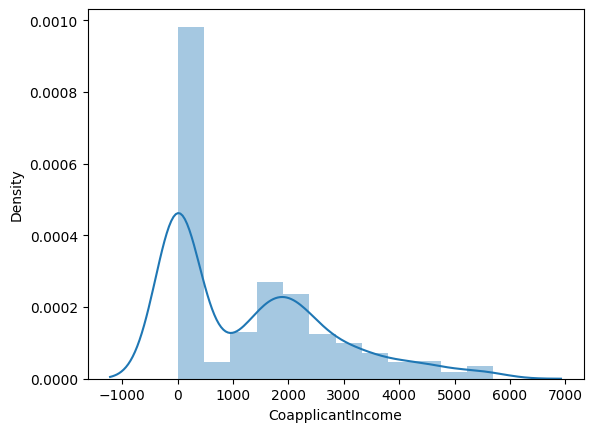

In [11]:
sns.distplot(loan_df.CoapplicantIncome)
plt.show()

In [12]:
from sklearn.preprocessing import FunctionTransformer

In [13]:
ft = FunctionTransformer(func=np.log1p)

In [14]:
ft.fit(loan_df[["CoapplicantIncome"]])

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [15]:
loan_df['CoapplicantIncome_ft'] = ft.transform(loan_df[["CoapplicantIncome"]])

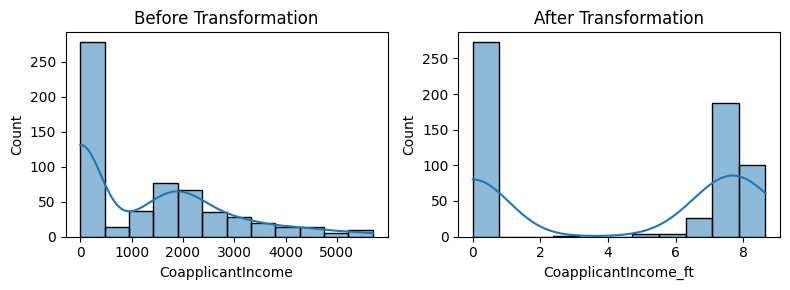

In [16]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
sns.histplot(loan_df['CoapplicantIncome'], kde=True)
plt.title('Before Transformation')

plt.subplot(1,2,2)
sns.histplot(loan_df['CoapplicantIncome_ft'], kde=True)
plt.title('After Transformation')

plt.tight_layout()
plt.show()

The original CoapplicantIncome data was highly right-skewed, where most values were concentrated near the lower range while a few very large values created a long tail toward the right. Such skewed data can negatively affect statistical analysis and machine learning models because extreme values dominate the distribution.

To reduce this skewness, a log transformation was applied, creating the new feature CoapplicantIncome_ft. After transformation, the distribution became more balanced and closer to a normal distribution. The large values were compressed while smaller values remained relatively distinguishable, making the data easier to analyze and improving model performance and stability.

---
Now I will perform the same Transformation but without removing the outliers

In [17]:
file_path = "loan.csv" 

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "tanishaj225/loancsv",  
    path=file_path
)

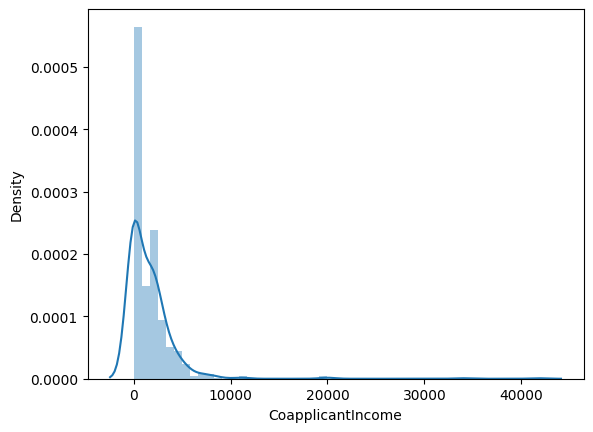

In [18]:
sns.distplot(df.CoapplicantIncome)
plt.show()

In [19]:
ft1 = FunctionTransformer(func=np.log1p)

In [20]:
ft1.fit(df[['CoapplicantIncome']])

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<ufunc 'log1p'>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [21]:
df['CoapplicantIncome_ft'] = ft.transform(df[["CoapplicantIncome"]])

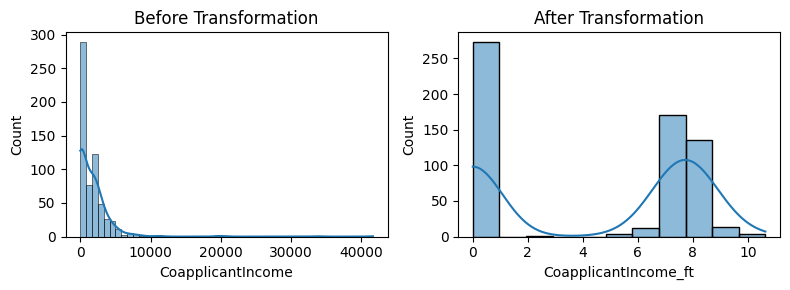

In [22]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
sns.histplot(df['CoapplicantIncome'], kde=True)
plt.title('Before Transformation')

plt.subplot(1,2,2)
sns.histplot(df['CoapplicantIncome_ft'], kde=True)
plt.title('After Transformation')

plt.tight_layout()
plt.show()

#### Why is still the same? Then Why should I remove the outliers?

Even after applying a transformation, some outliers may still appear in the data because transformation mainly reduces the effect of extreme values rather than completely removing them. The purpose of transformation is to make the data distribution more balanced and reduce skewness while preserving all observations. This is useful when the outliers contain important real-world information and should not be discarded.

For example, in financial or income datasets, extremely high values may represent genuine cases rather than errors. In such situations, transformations like log or square root transformation help control the influence of those values without losing important information.

However, if the outliers are caused by data entry mistakes, noise, or irrelevant observations, then removing them may be a better choice. Removing unnecessary outliers can improve model accuracy, reduce bias, and make patterns in the data easier to observe. Therefore, the decision depends on whether the outliers are meaningful or harmful to the analysis.

Let's try Funtion Transformer using some other funtion

In [23]:
ft2 = FunctionTransformer(func= lambda x : x ** 2)

In [24]:
ft2.fit(df[['CoapplicantIncome']])

,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function <la...0020862C5CF40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",None
,"inv_kw_args inv_kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to inverse_func... versionadded:: 0.18",None


In [25]:
df['CoapplicantIncome_ft1'] = ft2.transform(df[['CoapplicantIncome']])

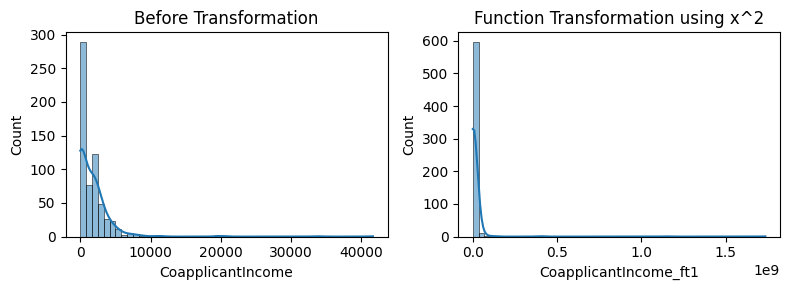

In [26]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
sns.histplot(df['CoapplicantIncome'], kde=True)
plt.title('Before Transformation')

plt.subplot(1,2,2)
sns.histplot(df['CoapplicantIncome_ft1'], kde=True)
plt.title('Function Transformation using x^2')

plt.tight_layout()
plt.show()

#### What is the problem with the after transformation using X^2

The square transformation was not suitable for this dataset because the feature was heavily right-skewed. Squaring the values increased the magnitude of large outliers significantly, causing the distribution to stretch excessively toward the right. As a result, most normal values became compressed near zero in the graph. Square transformation is generally more useful for left-skewed data, while log or square root transformations are better choices for right-skewed distributions.